In [2]:
import gzip

#################
##### FASTA #####
#################

def reading_dnaFasta(filename):
    infile = open(filename, 'r')
    header = ''
    sequence = ''

    for line in infile:
        line = line.strip()
        if line.startswith('>'):
            if header != '':
                yield header, sequence
            header = line[1:]
            sequence = ''
        else:
            sequence += line

    if sequence != '':
        yield header, sequence

    infile.close()


def fasta_length(filename):
    gene_length = {}
    for header, seq in reading_dnaFasta(filename):
        gene_length[header.strip().split(' ')[0]] = len(seq)
    return gene_length


def reverse_com_strand(sequence):
    comp = {'A': 'T', 'T': 'A', 'G': 'C', 'C': 'G'}
    rev = []
    for base in sequence[::-1]:
        if base in comp:
            rev.append(comp[base])
        else:
            rev.append('N')
    return ''.join(rev)


def nineteen_pos(DNA):
    for i in range(len(DNA) - 18):
        kmer = DNA[i:i+19]
        if 'N' not in kmer:
            yield i, kmer


def create_dict_kmer(fasta_file):

    kmer_index = {}

    for header, sequence in reading_dnaFasta(fasta_file):
        gene_name = header.strip().split(' ')[0]

        for strand in [sequence, reverse_com_strand(sequence)]:
            for position, kmer in nineteen_pos(strand):
                if kmer not in kmer_index:
                    kmer_index[kmer] = []
                kmer_index[kmer].append((gene_name, position))

    return kmer_index


#################
##### FASTQ #####
#################

def fastqread(filename):
    infile = gzip.open(filename, 'rt')
    while True:
        infile.readline()                # @header
        seq = infile.readline().rstrip() # sequence
        infile.readline()                # +
        infile.readline()                # quality

        if len(seq) == 0:
            break
        yield seq

    infile.close()


def matching_reads_to_reference(fastq_files, resistance_kmer, gene_length):

    dict_depth = {gene_name: [0] * length for gene_name, length in gene_length.items()}
    dict_unique_hits = {gene_name: 0 for gene_name in gene_length}

    for fastq_file in fastq_files:
        for seq in fastqread(fastq_file):

            read_length = len(seq)
            if read_length < 19:
                continue

            # Pre-screen: probe every ~20th k-mer of the read.
            # A real resistance read has ~80 matching k-mers, so checking
            # 5 spots catches it almost always. Random reads are skipped.
            possible_hit = False
            for probe_pos in range(0, read_length - 18, 20):
                kmer_probe = seq[probe_pos:probe_pos + 19]
                if 'N' in kmer_probe:
                    continue
                if kmer_probe in resistance_kmer:
                    possible_hit = True
                    break

            if not possible_hit:
                continue

            # Full scan: only for reads that passed the pre-screen.
            reads_found_gene = {}

            for read_pos in range(read_length - 18):
                kmer_read = seq[read_pos:read_pos + 19]
                '''
                if 'N' in kmer_read:
                    continue'''
                if kmer_read not in resistance_kmer:
                    continue

                entries = resistance_kmer[kmer_read]

                # Check if this k-mer maps uniquely to one gene only.
                first_gene = entries[0][0]
                unique = True
                for gene_name, position in entries:
                    if gene_name != first_gene:
                        unique = False
                        break

                for gene, gene_pos in entries:
                    alignment_shift = gene_pos - read_pos
                    evidence = (gene, alignment_shift)

                    if evidence not in reads_found_gene:
                        reads_found_gene[evidence] = [0, 0, []]

                    reads_found_gene[evidence][0] += 1   # total k-mer hits
                    if unique:
                        reads_found_gene[evidence][1] += 1   # unique hits
                    reads_found_gene[evidence][2].append(gene_pos)

            if not reads_found_gene:
                continue

            # Credit ALL plausible alignments, not just the best one,
            # so homologs that share k-mers each accumulate their own evidence.
            for evidence, info in reads_found_gene.items():
                gene = evidence[0]
                hits_total = info[0]
                unique_hits = info[1]
                hits = info[2]

                # filter out freak single-kmer accidents
                if hits_total < 2:
                    continue

                gene_depth = dict_depth[gene]
                for gene_pos in hits:
                    gene_depth[gene_pos] += 1
                dict_unique_hits[gene] += unique_hits

    return dict_depth, dict_unique_hits


#################
##### STATS #####
#################

def calculate_coverage_depth(dict_depth, gene_length, min_cov=95, min_depth=10):

    filtered_genes = {}
    k = 19

    for gene, list_depth in dict_depth.items():

        total_gene_length = gene_length[gene]
        core_start = k - 1
        core_end = total_gene_length - (k - 1)

        if core_end <= core_start:
            continue

        core_depth = list_depth[core_start:core_end]
        core_lenght = len(core_depth)

        covered_pos = sum(1 for d in core_depth if d > 0)
        coverage = (covered_pos / core_lenght) * 100
        average_depth = sum(core_depth) / core_lenght
        min_depth_obs = min(core_depth)

        if coverage >= min_cov and average_depth >= min_depth:
            filtered_genes[gene] = {
                'coverage': coverage,
                'depth': average_depth,
                'min_depth': min_depth_obs,
            }

    return filtered_genes


def cluster_genes_by_similarity(resistance_kmer, gene_length, filtered_genes,
                                dict_unique_hits, threshold=0.5):
    '''
    Compare pairs of genes that passed the coverage/depth filter.
    If two genes share a big fraction of their reference k-mers, they are
    near-homologs (e.g. blaTEM-1A vs blaTEM-1B). Keep the one with stronger
    evidence (coverage, then depth, then unique k-mer hits).
    '''

    # Build a gene -> set of reference k-mers from the kmer index.
    gene_kmers = {gene: set() for gene in gene_length}
    for kmer, entries in resistance_kmer.items():
        for gene, position in entries:
            gene_kmers[gene].add(kmer)

    # Only compare genes that actually passed the filter — much smaller list.
    gene_list = list(filtered_genes.keys())

    removed_genes = set()

    for i in range(len(gene_list)):
        for j in range(i + 1, len(gene_list)):
            gene_a = gene_list[i]
            gene_b = gene_list[j]

            # Skip if one was already removed in a previous comparison
            if gene_a in removed_genes or gene_b in removed_genes:
                continue

            kmers_a = gene_kmers[gene_a]
            kmers_b = gene_kmers[gene_b]

            # Jaccard similarity of reference k-mer sets
            shared_kmers = len(kmers_a.intersection(kmers_b))
            if shared_kmers == 0:
                continue

            if len(kmers_a) > len(kmers_b):    
                kmers_a, kmers_b = kmers_b, kmers_a

            similarity = shared_kmers / len(kmers_a)

            if similarity >= threshold:
                stats_a = filtered_genes[gene_a]
                stats_b = filtered_genes[gene_b]

                # Pick winner: coverage first, then depth, then unique hits
                if stats_a['coverage'] > stats_b['coverage']:
                    better = gene_a
                    worse = gene_b
                elif stats_b['coverage'] > stats_a['coverage']:
                    better = gene_b
                    worse = gene_a
                elif stats_a['depth'] > stats_b['depth']:
                    better = gene_a
                    worse = gene_b
                elif stats_b['depth'] > stats_a['depth']:
                    better = gene_b
                    worse = gene_a
                # final tie-breaker: uniquely-mapping k-mer hits
                elif dict_unique_hits[gene_a] >= dict_unique_hits[gene_b]:
                    better = gene_a
                    worse = gene_b
                else:
                    better = gene_b
                    worse = gene_a

                removed_genes.add(worse)

    final = {}
    for gene_name in filtered_genes.keys():
        if gene_name not in removed_genes:
            final[gene_name] = {
                'Gene': gene_name,
                'Cov': filtered_genes[gene_name]['coverage'],
                'Depth': filtered_genes[gene_name]['depth'],
                'MinDepth': filtered_genes[gene_name]['min_depth'],
            }

    return final


#################
##### MAIN ######
#################

if __name__ == '__main__':

    fasta_file = 'resistance_genes.fsa.txt'
    fastq_files = ['Unknown3_raw_reads_1.txt.gz', 'Unknown3_raw_reads_2.txt.gz']

    gene_length = fasta_length(fasta_file)
    resistance_kmer = create_dict_kmer(fasta_file)

    dict_depth, dict_unique_hits = matching_reads_to_reference(
        fastq_files, resistance_kmer, gene_length)

    filtered_genes = calculate_coverage_depth(
        dict_depth, gene_length, min_cov=95, min_depth=10)

    final_results = cluster_genes_by_similarity(
        resistance_kmer, gene_length,
        filtered_genes, dict_unique_hits,
        threshold=0.5)

    # Sort so the most certain hits come first.
    sorted_results = sorted(
        final_results.items(),
        key=lambda kv: (kv[1]['Cov'], kv[1]['Depth']),
        reverse=True)

    for family, info in sorted_results:
        gene = info['Gene']
        print(f"{gene} {info['Cov']}% {info['Depth']}")





fosA_3_ACWO01000079 100.0% 105.29427083333333
catB4_1_EU935739 100.0% 87.03118908382066
oqxA_1_EU370913 100.0% 82.7078947368421
blaSHV-28_1_HM751101 100.0% 62.473939393939396
tet(A)_4_AJ517790 100.0% 49.65034364261168
aac(6')Ib-cr_1_DQ303918 100.0% 43.554964539007095
aac(3)-IIa_1_CP023555.1 100.0% 42.03757575757576
strB_1_M96392 100.0% 41.57303370786517
blaTEM-1B_1_JF910132 100.0% 40.15151515151515
blaOXA-1_1_J02967 100.0% 39.67672955974843
strA_4_AF321551 100.0% 39.044270833333336
blaCTX-M-15_23_DQ302097 100.0% 38.892857142857146
dfrA14_1_DQ388123 100.0% 38.13870246085011
sul2_2_GQ421466 100.0% 33.69102564102564
oqxB_1_EU370913 97.85049727301893% 76.15014436958614


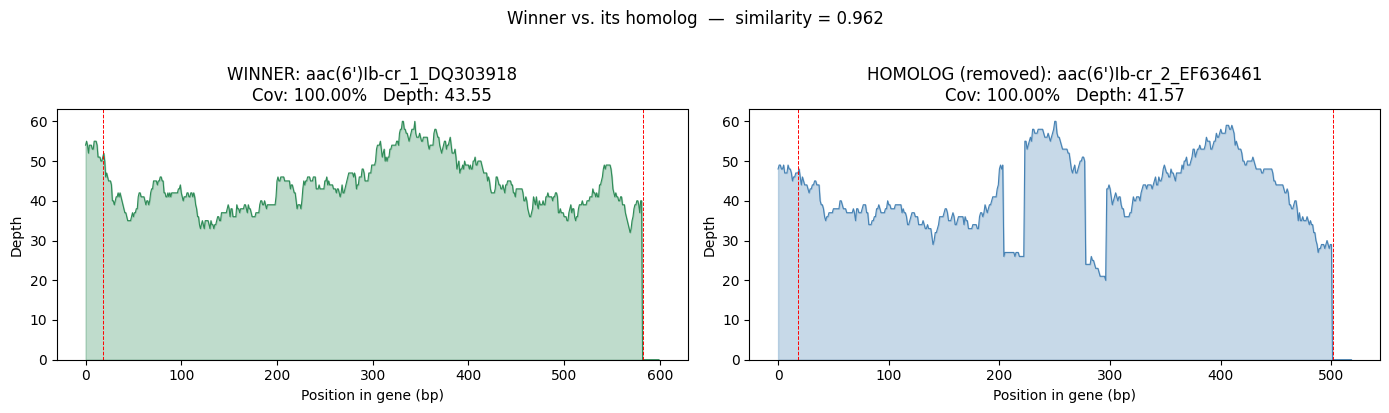

  Winner:  aac(6')Ib-cr_1_DQ303918  (Cov 100.00%, Depth 43.55)
  Homolog: aac(6')Ib-cr_2_EF636461  (Cov 100.00%, Depth 41.57)
  Depth ratio: 0.95
  Similarity:  0.962


In [6]:

# for plot
import sys
!{sys.executable} -m pip install matplotlib
import matplotlib.pyplot as plt
import random

## PLOTS

%matplotlib inline

import matplotlib.pyplot as plt
import random


%matplotlib inline

import matplotlib.pyplot as plt
import random


def plot_winner_vs_homolog(resistance_kmer, gene_length, filtered_genes,
                           final_results, dict_depth, threshold=0.5):
    '''
    Pick a random gene from the final 15 winners, then find a homolog of it
    (a gene similar above the threshold) that did NOT make it into the final
    results AND has noticeably lower depth than the winner. Plot the two
    side by side: winner on the left, lower-depth homolog on the right.
    '''

    k = 19

    # Build gene -> set of reference k-mers (same as clustering).
    gene_kmers = {gene: set() for gene in gene_length}
    for kmer, entries in resistance_kmer.items():
        for gene, position in entries:
            gene_kmers[gene].add(kmer)

    final_genes = list(final_results.keys())
    random.shuffle(final_genes)

    chosen_winner = None
    chosen_loser = None
    chosen_similarity = 0.0

    for winner in final_genes:
        kmers_w = gene_kmers[winner]
        winner_depth = filtered_genes[winner]['depth']

        candidates = []
        for gene in filtered_genes:
            if gene == winner:
                continue
            if gene in final_results:
                continue   # only "losers" allowed

            kmers_g = gene_kmers[gene]
            shared = len(kmers_w.intersection(kmers_g))
            if shared == 0:
                continue

            smaller = min(len(kmers_w), len(kmers_g))
            similarity = shared / smaller

            if similarity < threshold:
                continue

            # Only keep homologs whose depth is clearly lower than the winner's.
            # We want a small but visible difference — say, 5–40% lower.
            gene_depth = filtered_genes[gene]['depth']
            if gene_depth >= winner_depth:
                continue

            depth_ratio = gene_depth / winner_depth   # < 1 means lower
            if depth_ratio < 0.5:
                # Too far below — would look like a "fail" gene, not a homolog story.
                continue

            candidates.append((gene, similarity, depth_ratio))

        if candidates:
            # Sort by depth_ratio descending: pick the homolog whose depth is
            # closest to the winner but still lower. That gives a subtle,
            # honest visual difference rather than a dramatic one.
            candidates.sort(key=lambda x: x[2], reverse=True)
            chosen_winner = winner
            chosen_loser, chosen_similarity, _ = candidates[0]
            break

    if chosen_winner is None:
        print(f"No winner found with a similar but lower-depth homolog at threshold {threshold}.")
        print("Try lowering the threshold to surface more pairs.")
        return

    depth_w = dict_depth[chosen_winner]
    depth_l = dict_depth[chosen_loser]
    info_w = filtered_genes[chosen_winner]
    info_l = filtered_genes[chosen_loser]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # ---- Left: WINNER ----
    positions_w = list(range(len(depth_w)))
    axes[0].plot(positions_w, depth_w, color='seagreen', linewidth=0.8)
    axes[0].fill_between(positions_w, depth_w, color='seagreen', alpha=0.3)
    axes[0].axvline(x=k - 1, color='red', linestyle='--', linewidth=0.7)
    axes[0].axvline(x=len(depth_w) - (k - 1), color='red', linestyle='--', linewidth=0.7)
    axes[0].set_title(f"WINNER: {chosen_winner}\n"
                      f"Cov: {info_w['coverage']:.2f}%   "
                      f"Depth: {info_w['depth']:.2f}")
    axes[0].set_xlabel('Position in gene (bp)')
    axes[0].set_ylabel('Depth')

    # ---- Right: HOMOLOG (lower depth) ----
    positions_l = list(range(len(depth_l)))
    axes[1].plot(positions_l, depth_l, color='steelblue', linewidth=0.8)
    axes[1].fill_between(positions_l, depth_l, color='steelblue', alpha=0.3)
    axes[1].axvline(x=k - 1, color='red', linestyle='--', linewidth=0.7)
    axes[1].axvline(x=len(depth_l) - (k - 1), color='red', linestyle='--', linewidth=0.7)
    axes[1].set_title(f"HOMOLOG (removed): {chosen_loser}\n"
                      f"Cov: {info_l['coverage']:.2f}%   "
                      f"Depth: {info_l['depth']:.2f}")
    axes[1].set_xlabel('Position in gene (bp)')
    axes[1].set_ylabel('Depth')

    # Use the same y-axis on both panels so the depth difference is visible.
    ymax = max(max(depth_w), max(depth_l)) * 1.05
    axes[0].set_ylim(0, ymax)
    axes[1].set_ylim(0, ymax)

    fig.suptitle(f"Winner vs. its homolog  —  similarity = {chosen_similarity:.3f}",
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"  Winner:  {chosen_winner}  (Cov {info_w['coverage']:.2f}%, "
          f"Depth {info_w['depth']:.2f})")
    print(f"  Homolog: {chosen_loser}  (Cov {info_l['coverage']:.2f}%, "
          f"Depth {info_l['depth']:.2f})")
    print(f"  Depth ratio: {info_l['depth'] / info_w['depth']:.2f}")
    print(f"  Similarity:  {chosen_similarity:.3f}")


plot_winner_vs_homolog(resistance_kmer, gene_length, filtered_genes,
                       final_results, dict_depth, threshold=0.5)



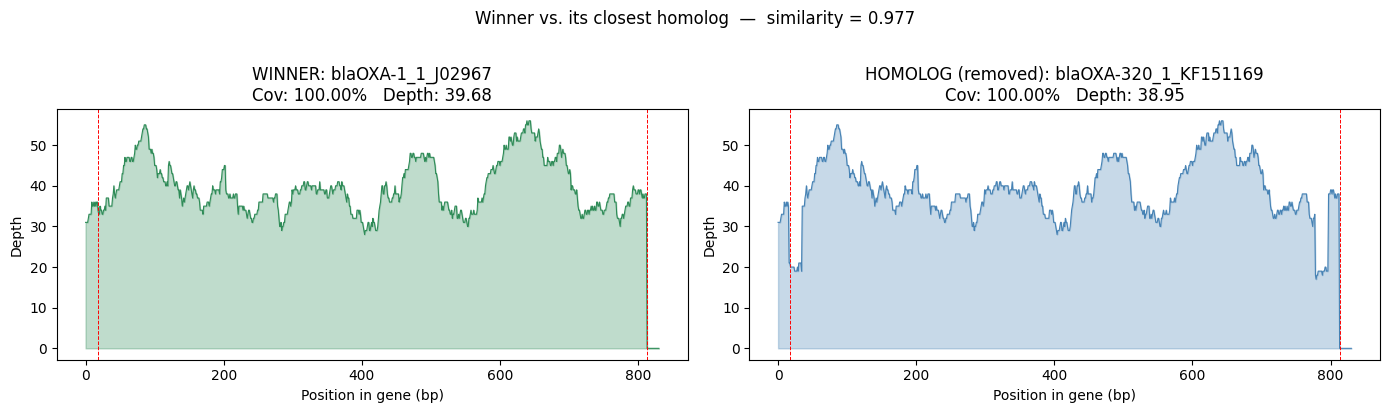

  Winner: blaOXA-1_1_J02967  (Cov 100.00%, Depth 39.68)
  Homolog: blaOXA-320_1_KF151169  (Cov 100.00%, Depth 38.95)
  Similarity: 0.977


In [38]:
%matplotlib inline

import matplotlib.pyplot as plt
import random


def plot_winner_vs_homolog(resistance_kmer, gene_length, filtered_genes,
                           final_results, dict_depth, threshold=0.5):
    '''
    Pick a random gene from the final 15 winners, then find a homolog of it
    (a gene similar above the threshold) that did NOT make it into the final
    results. Plot the two side by side: winner on the left, lesser homolog
    on the right.
    '''

    k = 19

    # Build gene -> set of reference k-mers (same as clustering).
    gene_kmers = {gene: set() for gene in gene_length}
    for kmer, entries in resistance_kmer.items():
        for gene, position in entries:
            gene_kmers[gene].add(kmer)

    final_genes = list(final_results.keys())

    # Try to find a winner that has at least one similar homolog
    # in filtered_genes that DID NOT make the final cut.
    random.shuffle(final_genes)

    chosen_winner = None
    chosen_loser = None
    chosen_similarity = 0.0

    for winner in final_genes:
        kmers_w = gene_kmers[winner]

        # Look for homologs of this winner among filtered_genes
        # that are NOT in final_results (i.e. were removed by clustering).
        candidates = []
        for gene in filtered_genes:
            if gene == winner:
                continue
            if gene in final_results:
                continue   # we want a "loser", not another winner

            kmers_g = gene_kmers[gene]
            shared = len(kmers_w.intersection(kmers_g))
            if shared == 0:
                continue

            smaller = min(len(kmers_w), len(kmers_g))
            similarity = shared / smaller

            if similarity >= threshold:
                candidates.append((gene, similarity))

        if candidates:
            # Pick the most similar homolog for the cleanest figure
            candidates.sort(key=lambda x: x[1], reverse=True)
            chosen_winner = winner
            chosen_loser, chosen_similarity = candidates[0]
            break

    if chosen_winner is None:
        print(f"No winner has a similar non-winning homolog at threshold {threshold}.")
        print("Try lowering the threshold to surface more pairs.")
        return

    depth_w = dict_depth[chosen_winner]
    depth_l = dict_depth[chosen_loser]
    info_w = filtered_genes[chosen_winner]
    info_l = filtered_genes[chosen_loser]

    # Set up two subplots side by side
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # ---- Left: WINNER (in final 15) ----
    positions_w = list(range(len(depth_w)))
    axes[0].plot(positions_w, depth_w, color='seagreen', linewidth=0.8)
    axes[0].fill_between(positions_w, depth_w, color='seagreen', alpha=0.3)
    axes[0].axvline(x=k - 1, color='red', linestyle='--', linewidth=0.7)
    axes[0].axvline(x=len(depth_w) - (k - 1), color='red', linestyle='--', linewidth=0.7)
    axes[0].set_title(f"WINNER: {chosen_winner}\n"
                      f"Cov: {info_w['coverage']:.2f}%   "
                      f"Depth: {info_w['depth']:.2f}")
    axes[0].set_xlabel('Position in gene (bp)')
    axes[0].set_ylabel('Depth')

    # ---- Right: HOMOLOG (removed by clustering) ----
    positions_l = list(range(len(depth_l)))
    axes[1].plot(positions_l, depth_l, color='steelblue', linewidth=0.8)
    axes[1].fill_between(positions_l, depth_l, color='steelblue', alpha=0.3)
    axes[1].axvline(x=k - 1, color='red', linestyle='--', linewidth=0.7)
    axes[1].axvline(x=len(depth_l) - (k - 1), color='red', linestyle='--', linewidth=0.7)
    axes[1].set_title(f"HOMOLOG (removed): {chosen_loser}\n"
                      f"Cov: {info_l['coverage']:.2f}%   "
                      f"Depth: {info_l['depth']:.2f}")
    axes[1].set_xlabel('Position in gene (bp)')
    axes[1].set_ylabel('Depth')

    fig.suptitle(f"Winner vs. its closest homolog  —  similarity = {chosen_similarity:.3f}",
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"  Winner: {chosen_winner}  (Cov {info_w['coverage']:.2f}%, "
          f"Depth {info_w['depth']:.2f})")
    print(f"  Homolog: {chosen_loser}  (Cov {info_l['coverage']:.2f}%, "
          f"Depth {info_l['depth']:.2f})")
    print(f"  Similarity: {chosen_similarity:.3f}")


plot_winner_vs_homolog(resistance_kmer, gene_length, filtered_genes,
                       final_results, dict_depth, threshold=0.5)